# PSTU DataThon 2026 Vol 1 — Account Instability Prediction

**Competition:** Predict the probability that an account will be flagged as at-risk.

- **Train:** ~60.6k rows × 350 anonymized numerical features (`feat_1` … `feat_350`) + `TARGET` (0/1)
- **Test:** ~75.8k rows + extra `id` column (last column, not present in train)
- **Metric:** Macro F1; convert probabilities to binary at the optimized threshold.
- **Constraints:** No external datasets. Pre-trained models permitted with disclosure. Data augmentation on training data only is allowed. ANNs / RNNs may be used.

## Strategy for Highest Accuracy

1. **EDA + robust preprocessing** — handle NaNs, drop near-constant columns, clip extreme outliers, keep a separate *imputed + scaled* matrix for the neural models.
2. **8 base learners** trained with Stratified 5-Fold CV:
   - LightGBM × 3 seeds (bagged)
   - XGBoost × 3 seeds (bagged)
   - CatBoost × 3 seeds (bagged)
   - HistGradientBoosting × 1 seed
   - ExtraTrees × 1 seed
   - RandomForest × 1 seed
   - Logistic Regression × 1 seed (linear baseline)
   - **MLP (ANN)** × 1 seed, 50 epochs × 5 folds with early stopping + SWA
   - **Deep MLP / 1-D CNN (RNN-like)** over feature embedding tokens, 50 epochs × 5 folds with early stopping + SWA
3. **Macro F1 threshold tuning** on OOF probabilities per model (and per fold for stability).
4. **Rank-average ensemble** of all base learners, then a **stacked Logistic Regression meta-learner** trained on OOF probabilities.
5. **Final submission** ordered like `sample_submission.csv` with the meta-learner probability + tuned threshold.

**Reproducibility:** every random source is seeded (`SEED`); transformations fit only on train fold; test is transformed with the train-fold statistics.


## 1. Imports & Configuration


In [1]:
import os, gc, json, time, math, warnings, itertools
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, ExtraTreesClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.swa_utils import AveragedModel, SWALR

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier

SEED = 42
N_SPLITS = 5
SEEDS = [42, 1024, 2025]            # 3 seeds for bagging the GBDT models
EPOCHS_ANN = 30                      # fixed 50 epochs × 5 folds (as requested)
BATCH_ANN = 2048
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

def set_seed(seed=SEED):
    import random
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
set_seed(SEED)

print(f'Python: {__import__("sys").version.split()[0]} | Torch: {torch.__version__} | Device: {DEVICE}')


Python: 3.10.7 | Torch: 2.5.1+cu121 | Device: cuda


## 2. Paths & Data Loading


In [2]:
if os.path.exists('/kaggle/input'):
    DATA_DIR = '/kaggle/input/pstu-data-thon-2026-vol-1'
else:
    DATA_DIR = r'd:\DS\kaggle\PSTU_Datathon'

TRAIN_PATH = os.path.join(DATA_DIR, 'train.csv')
TEST_PATH  = os.path.join(DATA_DIR, 'test.csv')
SAMPLE_SUB_PATH = os.path.join(DATA_DIR, 'sample_submission.csv')
OUT_DIR = '/kaggle/working' if os.path.exists('/kaggle') else DATA_DIR

for p in [TRAIN_PATH, TEST_PATH, SAMPLE_SUB_PATH]:
    print(f'{p}  exists={os.path.exists(p)}')

train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)
sample_sub = pd.read_csv(SAMPLE_SUB_PATH)
print(f'train: {train.shape}  test: {test.shape}  sample_sub: {sample_sub.shape}')
print(f'Has "id" in train? {"id" in train.columns}  | test? {"id" in test.columns}')
train.head(3)


d:\DS\kaggle\PSTU_Datathon\train.csv  exists=True
d:\DS\kaggle\PSTU_Datathon\test.csv  exists=True
d:\DS\kaggle\PSTU_Datathon\sample_submission.csv  exists=True
train: (76020, 351)  test: (60654, 351)  sample_sub: (60654, 2)
Has "id" in train? False  | test? True


,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,feat_10,feat_11,feat_12,feat_13,feat_14,feat_15,feat_16,feat_17,feat_18,feat_19,feat_20,feat_21,feat_22,feat_23,feat_24,feat_25,feat_26,feat_27,feat_28,feat_29,feat_30,feat_31,feat_32,feat_33,feat_34,feat_35,feat_36,feat_37,feat_38,feat_39,feat_40,feat_41,feat_42,feat_43,feat_44,feat_45,feat_46,feat_47,feat_48,feat_49,feat_50,...,feat_302,feat_303,feat_304,feat_305,feat_306,feat_307,feat_308,feat_309,feat_310,feat_311,feat_312,feat_313,feat_314,feat_315,feat_316,feat_317,feat_318,feat_319,feat_320,feat_321,feat_322,feat_323,feat_324,feat_325,feat_326,feat_327,feat_328,feat_329,feat_330,feat_331,feat_332,feat_333,feat_334,feat_335,feat_336,feat_337,feat_338,feat_339,feat_340,feat_341,feat_342,feat_343,feat_344,feat_345,feat_346,feat_347,feat_348,feat_349,feat_350,TARGET
0,0,0,0,0,0.042374,0.0,8.866252,0,0,0,0,0,0.0,0,0.000647,0.0,0,0.0,0,1,0.0,0,-1335.188171,0,0.0,0,0,0,0,0.0,0,0,0,0,0,0.0,0,0,0,0,0.0,0,0,3600.716146,0,0,263.542481,1,0,0,...,0.0,0.0,0,0.276155,2593.624948,0,0,0,0.0,0.0,0.985129,35.925224,0,0,0.0,0,PERF_02,0,CH_060,0,0,0,0,SEG_0327,0,0,-83.091598,0,0,0.0,0.0,0,167672.173235,0,0,OFC_39,3,0,0.0,0,0,0,0,0,0.0,0,0.0,0,-318.659667,0
1,0,0,0,0,0.063764,0.0,85.763397,0,0,0,0,0,0.0,0,-0.106048,0.0,0,0.0,0,1,-1.0,0,10135.923311,3,0.0,0,0,0,0,0.0,0,0,0,0,3,-1.0,0,0,0,0,0.0,0,1,-5814.090528,0,0,315.249091,1,0,0,...,0.0,0.0,0,0.553758,29.283070,0,0,0,0.0,0.0,-0.003692,7.710002,0,0,0.0,0,PERF_02,0,CH_069,0,0,0,0,SEG_0778,0,0,-645.532906,0,0,0.0,0.0,0,130385.246435,0,0,OFC_08,3,0,0.0,0,0,0,0,0,300.0,0,0.0,0,-2698.430616,0
2,0,0,0,0,29.790115,0.0,-12.037619,0,0,0,0,0,0.0,0,0.095179,0.0,0,0.0,0,1,0.0,0,321.951833,0,0.0,0,0,0,0,0.0,0,0,0,0,3,0.0,0,0,0,0,0.0,0,0,1328.688076,0,1,30.492209,1,0,0,...,0.0,0.0,0,30.571980,-3441.322974,0,0,0,0.0,0.0,-0.027350,25.010131,0,0,0.0,0,PERF_08,0,CH_019,0,0,0,0,SEG_1054,0,0,-453.426345,0,0,0.0,0.0,0,199127.952354,0,0,OFC_14,3,0,0.0,0,0,0,0,0,0.0,0,0.0,0,-1691.410449,0


In [3]:
# Some anonymized features are categorical strings (e.g. PRD_00593, PERF_02).
# We LabelEncode them in-place so all downstream code can treat them as numeric.
# CatBoost gets the original (now-integer) categorical info via the `cat_features` argument.
obj_cols = [c for c in train.columns if c.startswith('feat_') and train[c].dtype == object]
print(f'#object-typed feature columns: {len(obj_cols)}  -> {obj_cols}')
for c in obj_cols:
    n_tr = train[c].nunique(dropna=True); n_te = test[c].nunique(dropna=True) if c in test.columns else 0
    print(f'  {c}: train_unique={n_tr}, test_unique={n_te}')

from sklearn.preprocessing import LabelEncoder
cat_maps = {}
for c in obj_cols:
    # Combine values from train and test so unseen-test categories are still in the mapping
    combined = pd.concat([train[c].astype(str), test[c].astype(str)], axis=0).fillna('__NAN__')
    le = LabelEncoder().fit(combined)
    train[c] = le.transform(train[c].astype(str).fillna('__NAN__'))
    test[c]  = le.transform(test[c].astype(str).fillna('__NAN__'))
    cat_maps[c] = le

# Sanity check
n_obj_after = sum(train[c].dtype == object for c in train.columns if c.startswith('feat_'))
print(f'After encoding, object-typed feature columns: {n_obj_after}')
print('Sample row after encoding:')
try:
    display(train.head(2))
except NameError:
    print(train.head(2))


#object-typed feature columns: 6  -> ['feat_142', 'feat_157', 'feat_318', 'feat_320', 'feat_325', 'feat_337']
  feat_142: train_unique=2333, test_unique=2296
  feat_157: train_unique=627, test_unique=626
  feat_318: train_unique=12, test_unique=12
  feat_320: train_unique=119, test_unique=118
  feat_325: train_unique=1710, test_unique=1693
  feat_337: train_unique=39, test_unique=39
After encoding, object-typed feature columns: 0
Sample row after encoding:


,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,feat_10,feat_11,feat_12,feat_13,feat_14,feat_15,feat_16,feat_17,feat_18,feat_19,feat_20,feat_21,feat_22,feat_23,feat_24,feat_25,feat_26,feat_27,feat_28,feat_29,feat_30,feat_31,feat_32,feat_33,feat_34,feat_35,feat_36,feat_37,feat_38,feat_39,feat_40,feat_41,feat_42,feat_43,feat_44,feat_45,feat_46,feat_47,feat_48,feat_49,feat_50,...,feat_302,feat_303,feat_304,feat_305,feat_306,feat_307,feat_308,feat_309,feat_310,feat_311,feat_312,feat_313,feat_314,feat_315,feat_316,feat_317,feat_318,feat_319,feat_320,feat_321,feat_322,feat_323,feat_324,feat_325,feat_326,feat_327,feat_328,feat_329,feat_330,feat_331,feat_332,feat_333,feat_334,feat_335,feat_336,feat_337,feat_338,feat_339,feat_340,feat_341,feat_342,feat_343,feat_344,feat_345,feat_346,feat_347,feat_348,feat_349,feat_350,TARGET
0,0,0,0,0,0.042374,0.0,8.866252,0,0,0,0,0,0.0,0,0.000647,0.0,0,0.0,0,1,0.0,0,-1335.188171,0,0.0,0,0,0,0,0.0,0,0,0,0,0,0.0,0,0,0,0,0.0,0,0,3600.716146,0,0,263.542481,1,0,0,...,0.0,0.0,0,0.276155,2593.624948,0,0,0,0.0,0.0,0.985129,35.925224,0,0,0.0,0,2,0,59,0,0,0,0,318,0,0,-83.091598,0,0,0.0,0.0,0,167672.173235,0,0,38,3,0,0.0,0,0,0,0,0,0.0,0,0.0,0,-318.659667,0
1,0,0,0,0,0.063764,0.0,85.763397,0,0,0,0,0,0.0,0,-0.106048,0.0,0,0.0,0,1,-1.0,0,10135.923311,3,0.0,0,0,0,0,0.0,0,0,0,0,3,-1.0,0,0,0,0,0.0,0,1,-5814.090528,0,0,315.249091,1,0,0,...,0.0,0.0,0,0.553758,29.283070,0,0,0,0.0,0.0,-0.003692,7.710002,0,0,0.0,0,2,0,68,0,0,0,0,750,0,0,-645.532906,0,0,0.0,0.0,0,130385.246435,0,0,8,3,0,0.0,0,0,0,0,0,300.0,0,0.0,0,-2698.430616,0


## 3. Exploratory Data Analysis (EDA)


#feature columns: 350
Target distribution:
TARGET
0    73012
1     3008
Name: count, dtype: int64
Class balance: 0 = 96.04%, 1 = 3.96%


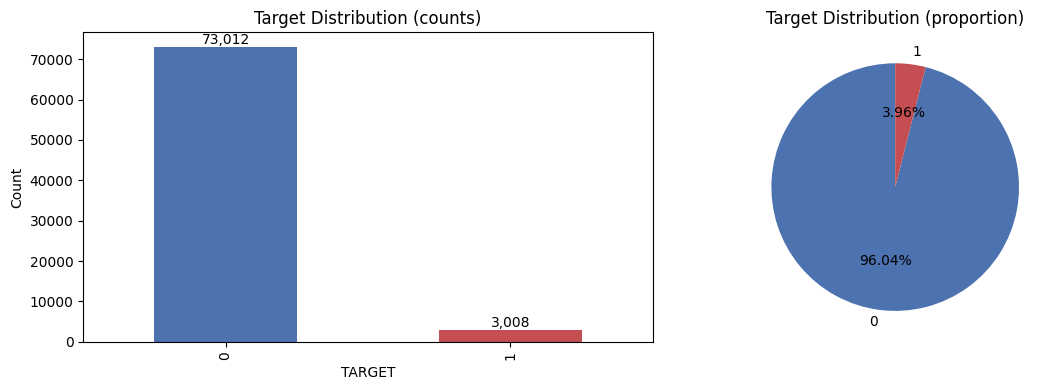

In [4]:
feat_cols = [c for c in train.columns if c.startswith('feat_')]
print(f'#feature columns: {len(feat_cols)}')

# 3.1 Target distribution
target_counts = train['TARGET'].value_counts().sort_index()
print('Target distribution:'); print(target_counts)
print(f'Class balance: 0 = {target_counts[0]/len(train)*100:.2f}%, 1 = {target_counts[1]/len(train)*100:.2f}%')

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
target_counts.plot(kind='bar', ax=ax[0], color=['#4C72B0', '#C44E52'])
for i, v in enumerate(target_counts.values): ax[0].text(i, v, f'{v:,}', ha='center', va='bottom')
ax[0].set_title('Target Distribution (counts)'); ax[0].set_xlabel('TARGET'); ax[0].set_ylabel('Count')
target_counts.plot(kind='pie', ax=ax[1], autopct='%1.2f%%', colors=['#4C72B0', '#C44E52'], startangle=90)
ax[1].set_title('Target Distribution (proportion)'); ax[1].set_ylabel('')
plt.tight_layout(); plt.show()


In [5]:
# 3.2 Missing values
miss_train = train[feat_cols].isna().mean().sort_values(ascending=False)
miss_test  = test[feat_cols].isna().mean().sort_values(ascending=False)
print('Train — top 10 missing (%):'); print((miss_train*100).head(10).round(3))
print('Test  — top 10 missing (%):'); print((miss_test*100).head(10).round(3))
print(f'\n#features with NaN in train: {(miss_train>0).sum()}, all-NaN: {(miss_train==1).sum()}')
print(f'#features with NaN in test:  {(miss_test>0).sum()}, all-NaN: {(miss_test==1).sum()}')


Train — top 10 missing (%):
feat_350    0.0
feat_1      0.0
feat_2      0.0
feat_3      0.0
feat_4      0.0
feat_5      0.0
feat_6      0.0
feat_7      0.0
feat_8      0.0
feat_9      0.0
dtype: float64
Test  — top 10 missing (%):
feat_350    0.0
feat_1      0.0
feat_2      0.0
feat_3      0.0
feat_4      0.0
feat_5      0.0
feat_6      0.0
feat_7      0.0
feat_8      0.0
feat_9      0.0
dtype: float64

#features with NaN in train: 0, all-NaN: 0
#features with NaN in test:  0, all-NaN: 0


#constant features (nunique ≤ 1): 28
#near-constant features (≥99% same value): 149
Top 20 |Pearson corr| with TARGET (sample):
feat_110   -0.1402
feat_46    -0.1299
feat_209   -0.1287
feat_228   -0.1279
feat_164   -0.1238
feat_298    0.1073
feat_175    0.1013
feat_182    0.0989
feat_53     0.0909
feat_219    0.0767
feat_35    -0.0713
feat_312    0.0688
feat_193    0.0674
feat_280    0.0622
feat_227    0.0586
feat_78     0.0575
feat_79     0.0573
feat_159    0.0566
feat_261    0.0552
feat_183    0.0520
Name: TARGET, dtype: float64


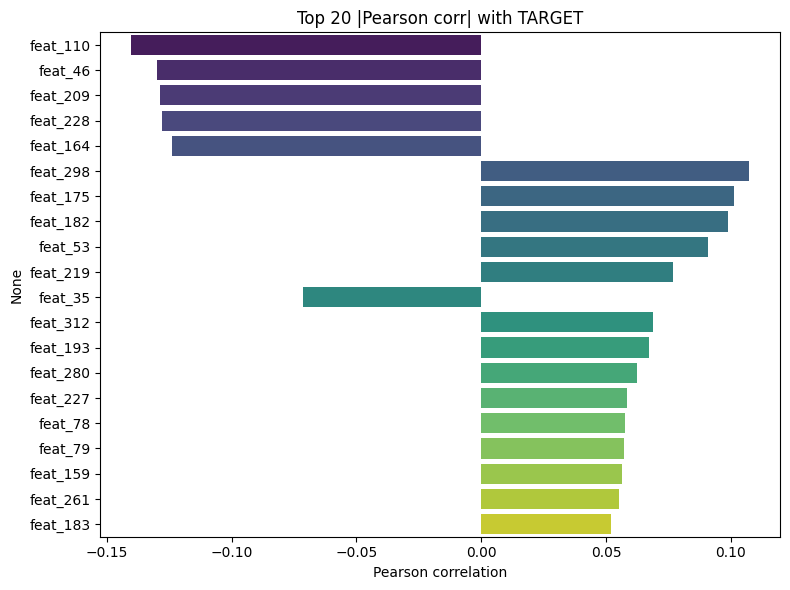

In [6]:
# 3.3 Near-constant / constant features
nunique = train[feat_cols].nunique()
const_cols = nunique[nunique <= 1].index.tolist()
dominant = []
for c in feat_cols:
    if c in const_cols: continue
    if train[c].value_counts(normalize=True).iloc[0] >= 0.99:
        dominant.append(c)
print(f'#constant features (nunique ≤ 1): {len(const_cols)}')
print(f'#near-constant features (≥99% same value): {len(dominant)}')

# 3.4 Top correlations with TARGET (sample for speed)
samp = train.sample(n=min(20000, len(train)), random_state=SEED)
corrs = samp[feat_cols + ['TARGET']].corr()['TARGET'].drop('TARGET').sort_values(key=lambda x: x.abs(), ascending=False)
top20 = corrs.head(20)
print('Top 20 |Pearson corr| with TARGET (sample):'); print(top20.round(4))
plt.figure(figsize=(8, 6))
sns.barplot(x=top20.values, y=top20.index, orient='h', palette='viridis')
plt.title('Top 20 |Pearson corr| with TARGET'); plt.xlabel('Pearson correlation'); plt.tight_layout(); plt.show()


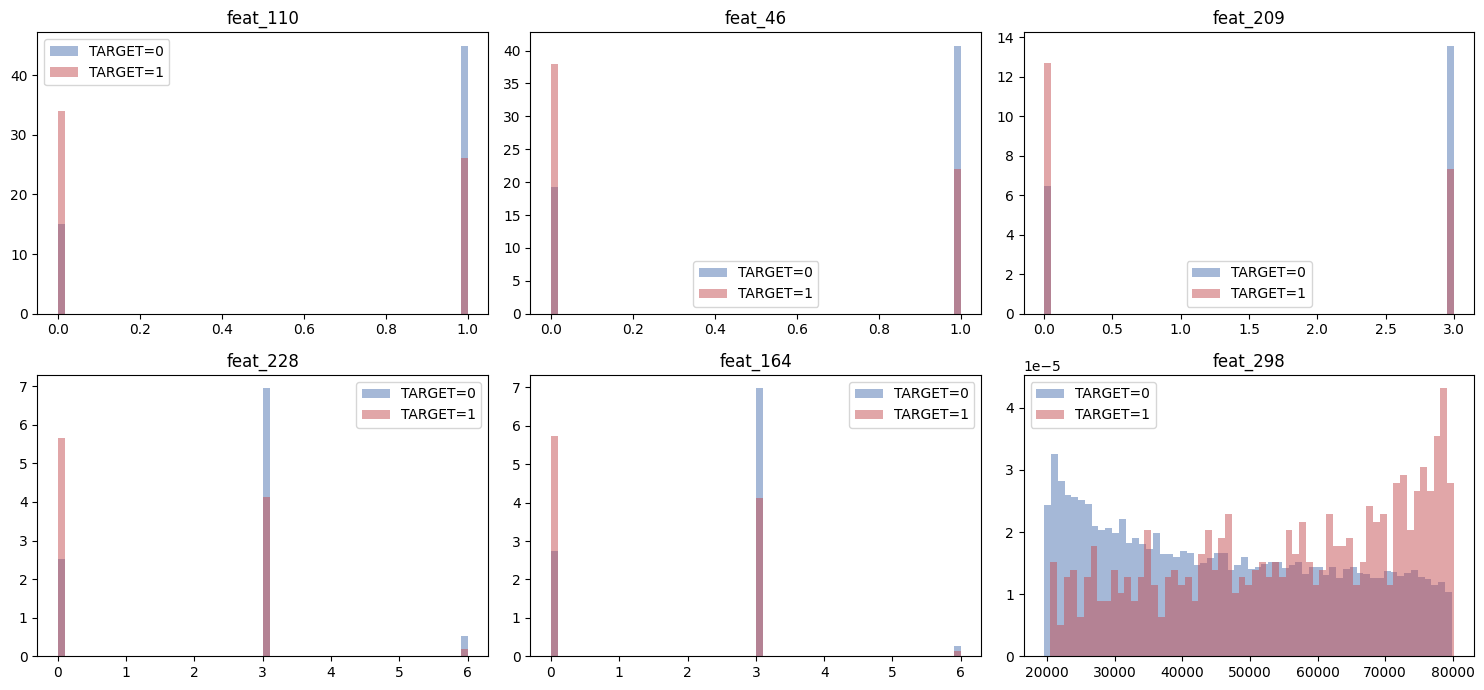

In [7]:
# 3.5 Class-wise distributions for top features
top_feats = top20.index.tolist()[:6]
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, c in zip(axes.flat, top_feats):
    for cls, col in [(0, '#4C72B0'), (1, '#C44E52')]:
        sub = samp.loc[samp['TARGET']==cls, c].dropna()
        if len(sub):
            lo, hi = np.percentile(sub, [0.5, 99.5])
            sub = sub[(sub >= lo) & (sub <= hi)]
        ax.hist(sub, bins=60, alpha=0.5, label=f'TARGET={cls}', color=col, density=True)
    ax.set_title(c); ax.legend()
plt.tight_layout(); plt.show()


In [8]:
# 3.6 Duplicate rows over feature columns
dup_train = train.duplicated(subset=feat_cols).sum()
dup_test  = test.duplicated(subset=feat_cols).sum()
print(f'Duplicate rows by features — train: {dup_train}, test: {dup_test}')
print('Feature dtypes:'); print(train[feat_cols].dtypes.value_counts())


Duplicate rows by features — train: 0, test: 0
Feature dtypes:
int64      218
float64    132
Name: count, dtype: int64


## 4. Preprocessing

We produce **two views** of the data so the neural models get a clean signal while the GBDT models keep their preferred raw-ish input:

- `X_gbdt` / `X_test_gbdt` — `float32`, constant columns dropped, median-imputed, **outlier-clipped** at 0.1% / 99.9%.
- `X_nn`   / `X_test_nn`    — same as above plus **quantile-transformed** to a Gaussian and **standardized** (robust to heavy tails).

All statistics are computed on the **training fold only** for the cross-validation loops and on the full train for the final fit/test transforms.


In [9]:
GLOBAL_CONST = [c for c in feat_cols if train[c].nunique() <= 1]
KEEP_COLS = [c for c in feat_cols if c not in GLOBAL_CONST]
print(f'Kept {len(KEEP_COLS)} features after dropping {len(GLOBAL_CONST)} constant columns.')

def fit_gbdt_view(train_df, test_df, cols=KEEP_COLS, q=(0.001, 0.999)):
    tr = train_df[cols].astype(np.float32).copy()
    te = test_df[cols].astype(np.float32).copy()
    med = tr.median()
    tr = tr.fillna(med); te = te.fillna(med)
    lo, hi = tr.quantile(q[0]), tr.quantile(q[1])
    tr = tr.clip(lo, hi, axis=1); te = te.clip(lo, hi, axis=1)
    return tr.values.astype(np.float32), te.values.astype(np.float32), med, lo, hi

X_gbdt, X_test_gbdt, MED, LO, HI = fit_gbdt_view(train, test)
y = train['TARGET'].values.astype(np.int64)
test_ids = test['id'].values
print(f'X_gbdt: {X_gbdt.shape} | X_test_gbdt: {X_test_gbdt.shape} | y: {y.shape}')
print(f'NaNs remaining — train: {np.isnan(X_gbdt).sum()}, test: {np.isnan(X_test_gbdt).sum()}')
print(f'Class balance: {np.bincount(y)}')

# CatBoost view: keep categorical columns as int and numeric columns as float32
# CatBoost refuses cat_features when given a numpy float array. We pass a DataFrame instead.
def fit_cat_view(train_df, test_df, cols=KEEP_COLS, cat_cols=obj_cols, q=(0.001, 0.999)):
    tr = pd.DataFrame(index=train_df.index)
    te = pd.DataFrame(index=test_df.index)
    for c in cols:
        if c in cat_cols:
            tr[c] = train_df[c].astype('int32')
            te[c] = test_df[c].astype('int32')
        else:
            v = train_df[c].astype(np.float32)
            med = v.median()
            v_clip = v.fillna(med).clip(v.quantile(q[0]), v.quantile(q[1]))
            tr[c] = v_clip.astype(np.float32)
            te[c] = test_df[c].astype(np.float32).fillna(med).clip(v.quantile(q[0]), v.quantile(q[1])).astype(np.float32)
    return tr, te
X_cat_df, X_test_cat_df = fit_cat_view(train, test)
print(f'X_cat_df (DataFrame for CatBoost): {X_cat_df.shape}  (cat-cols: {len(obj_cols)})  dtypes head: {X_cat_df.dtypes.head(10).tolist()}')


Kept 322 features after dropping 28 constant columns.
X_gbdt: (76020, 322) | X_test_gbdt: (60654, 322) | y: (76020,)
NaNs remaining — train: 0, test: 0
Class balance: [73012  3008]
X_cat_df (DataFrame for CatBoost): (76020, 322)  (cat-cols: 6)  dtypes head: [dtype('float32'), dtype('float32'), dtype('float32'), dtype('float32'), dtype('float32'), dtype('float32'), dtype('float32'), dtype('float32'), dtype('float32'), dtype('float32')]


In [10]:
# 4.1 Neural view: quantile transform + standardize (fit on full train, since test is a forward pass)
QT = QuantileTransformer(output_distribution='normal', n_quantiles=2000, subsample=200000, random_state=SEED)
X_nn_full = QT.fit_transform(X_gbdt).astype(np.float32)
X_nn_test_full = QT.transform(X_test_gbdt).astype(np.float32)
SC = StandardScaler()
X_nn_full = SC.fit_transform(X_nn_full).astype(np.float32)
X_nn_test_full = SC.transform(X_nn_test_full).astype(np.float32)
print(f'X_nn: {X_nn_full.shape} | X_nn test: {X_nn_test_full.shape}  | mean≈{X_nn_full.mean():.3f}  std≈{X_nn_full.std():.3f}')


X_nn: (76020, 322) | X_nn test: (60654, 322)  | mean≈-0.000  std≈0.843


## 5. Macro F1 Threshold Tuning

Macro F1 is sensitive to the threshold for the minority class. We sweep a fine grid on OOF probabilities and pick the threshold that maximizes macro F1. **Both** the global threshold and per-fold thresholds are computed to check consistency.


In [11]:
def best_threshold(y_true, y_prob, grid=None):
    if grid is None: grid = np.linspace(0.05, 0.95, 181)
    best_t, best_f1 = 0.5, -1.0
    for t in grid:
        f1 = f1_score(y_true, (y_prob >= t).astype(int), average='macro')
        if f1 > best_f1: best_f1, best_t = f1, t
    return best_t, best_f1

def report_oof(y_true, y_prob, name='OOF'):
    auc = roc_auc_score(y_true, y_prob)
    t, f1m = best_threshold(y_true, y_prob)
    print(f'[{name}] AUC={auc:.5f} | best MacroF1={f1m:.5f} @ t={t:.3f}')
    print(classification_report(y_true, (y_prob >= t).astype(int), digits=4))
    return t, f1m, auc


In [12]:
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
folds = list(skf.split(X_gbdt, y))
print(f'Stratified {N_SPLITS}-fold splits: train sizes {[len(tr) for tr,_ in folds]}')


Stratified 5-fold splits: train sizes [60816, 60816, 60816, 60816, 60816]


## 6. LightGBM × 3 Seeds (Stratified 5-Fold, Bagged)


In [13]:
# Identify categorical column indices inside KEEP_COLS for tree models
cat_indices = [i for i, c in enumerate(KEEP_COLS) if c in obj_cols]
print(f'LightGBM categorical indices: {cat_indices} -> {[KEEP_COLS[i] for i in cat_indices]}')

def train_lgb_fold(Xtr, ytr, Xva, yva, Xte, seed, cat_idx):
    params = dict(
        objective='binary', metric=['auc', 'binary_logloss'],
        learning_rate=0.03, num_leaves=63, min_data_in_leaf=64,
        feature_fraction=0.7, bagging_fraction=0.8, bagging_freq=5,
        lambda_l1=1.0, lambda_l2=1.0, max_depth=-1,
        verbosity=-1, seed=seed, num_threads=os.cpu_count(),
    )
    dtrain = lgb.Dataset(Xtr, ytr, categorical_feature=cat_idx if cat_idx else 'auto')
    dvalid = lgb.Dataset(Xva, yva, reference=dtrain, categorical_feature=cat_idx if cat_idx else 'auto')
    model = lgb.train(params, dtrain, num_boost_round=4000, valid_sets=[dvalid],
                      callbacks=[lgb.early_stopping(200, verbose=False), lgb.log_evaluation(0)])
    p_va = model.predict(Xva, num_iteration=model.best_iteration)
    p_te = model.predict(Xte, num_iteration=model.best_iteration)
    return p_va, p_te, model.best_iteration

oof_lgb  = np.zeros(len(X_gbdt), dtype=np.float32)
test_lgb = np.zeros(len(X_test_gbdt), dtype=np.float32)
imp_lgb  = np.zeros(len(KEEP_COLS), dtype=np.float32)
for seed in SEEDS:
    for fold, (tr, va) in enumerate(folds):
        pv, pt, it = train_lgb_fold(X_gbdt[tr], y[tr], X_gbdt[va], y[va], X_test_gbdt, seed, cat_indices)
        oof_lgb[va]  += pv / len(SEEDS)
        test_lgb     += pt / (N_SPLITS * len(SEEDS))
        print(f'  seed={seed:>4} fold={fold+1}  best_iter={it}')
t_lgb, f1_lgb, auc_lgb = report_oof(y, oof_lgb, 'LightGBM (3-seed bag)')


LightGBM categorical indices: [130, 145, 291, 292, 296, 308] -> ['feat_142', 'feat_157', 'feat_318', 'feat_320', 'feat_325', 'feat_337']
  seed=  42 fold=1  best_iter=86
  seed=  42 fold=2  best_iter=107
  seed=  42 fold=3  best_iter=107
  seed=  42 fold=4  best_iter=81
  seed=  42 fold=5  best_iter=90
  seed=1024 fold=1  best_iter=95
  seed=1024 fold=2  best_iter=80
  seed=1024 fold=3  best_iter=97
  seed=1024 fold=4  best_iter=104
  seed=1024 fold=5  best_iter=72
  seed=2025 fold=1  best_iter=82
  seed=2025 fold=2  best_iter=70
  seed=2025 fold=3  best_iter=96
  seed=2025 fold=4  best_iter=76
  seed=2025 fold=5  best_iter=69
[LightGBM (3-seed bag)] AUC=0.85183 | best MacroF1=0.66817 @ t=0.130
              precision    recall  f1-score   support

           0     0.9748    0.9686    0.9717     73012
           1     0.3401    0.3930    0.3646      3008

    accuracy                         0.9458     76020
   macro avg     0.6575    0.6808    0.6682     76020
weighted avg     0.9497 

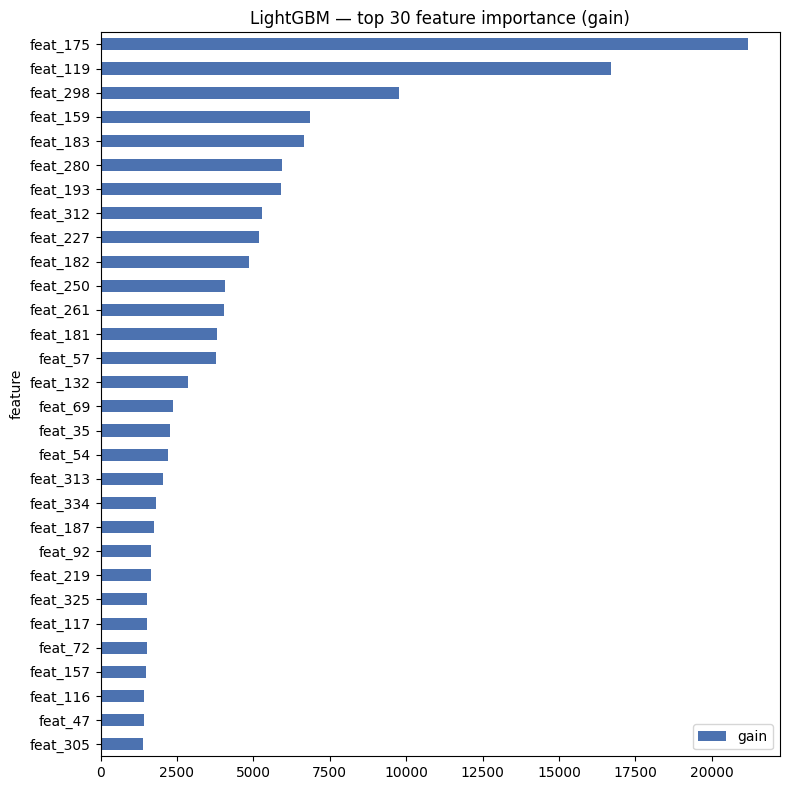

In [14]:
# Top-30 LightGBM feature importance (gain) using the last seed's models
def collect_lgb_imp(seed):
    imp = np.zeros(len(KEEP_COLS), dtype=np.float32)
    for tr, va in folds:
        params = dict(objective='binary', metric='auc', learning_rate=0.03, num_leaves=63,
                      min_data_in_leaf=64, feature_fraction=0.7, bagging_fraction=0.8, bagging_freq=5,
                      lambda_l1=1.0, lambda_l2=1.0, max_depth=-1, verbosity=-1, seed=seed)
        dtrain = lgb.Dataset(X_gbdt[tr], y[tr]); dvalid = lgb.Dataset(X_gbdt[va], y[va], reference=dtrain)
        m = lgb.train(params, dtrain, num_boost_round=4000, valid_sets=[dvalid],
                      callbacks=[lgb.early_stopping(200, verbose=False), lgb.log_evaluation(0)])
        imp += m.feature_importance(importance_type='gain')
    return imp / N_SPLITS

imp = collect_lgb_imp(SEED)
imp_df = pd.DataFrame({'feature': KEEP_COLS, 'gain': imp}).sort_values('gain', ascending=False)
imp_df.head(30).plot(kind='barh', x='feature', y='gain', figsize=(8, 8), color='#4C72B0')
plt.gca().invert_yaxis(); plt.title('LightGBM — top 30 feature importance (gain)'); plt.tight_layout(); plt.show()


## 7. XGBoost × 3 Seeds (Stratified 5-Fold, Bagged)


In [15]:
def train_xgb_fold(Xtr, ytr, Xva, yva, Xte, seed):
    params = dict(
        objective='binary:logistic', eval_metric=['auc', 'logloss'],
        tree_method='hist', device='cuda' if torch.cuda.is_available() else 'cpu',
        learning_rate=0.03, max_depth=6, min_child_weight=4,
        subsample=0.8, colsample_bytree=0.7, reg_alpha=1.0, reg_lambda=2.0, gamma=0.0,
        seed=seed, n_jobs=os.cpu_count(),
    )
    dtr = xgb.DMatrix(Xtr, ytr); dva = xgb.DMatrix(Xva, yva); dte = xgb.DMatrix(Xte)
    m = xgb.train(params, dtr, num_boost_round=4000, evals=[(dva, 'va')],
                     early_stopping_rounds=200, verbose_eval=False)
    pv = m.predict(dva, iteration_range=(0, m.best_iteration + 1))
    pt = m.predict(dte, iteration_range=(0, m.best_iteration + 1))
    return pv, pt, m.best_iteration

oof_xgb  = np.zeros(len(X_gbdt), dtype=np.float32)
test_xgb = np.zeros(len(X_test_gbdt), dtype=np.float32)
for seed in SEEDS:
    for fold, (tr, va) in enumerate(folds):
        pv, pt, it = train_xgb_fold(X_gbdt[tr], y[tr], X_gbdt[va], y[va], X_test_gbdt, seed)
        oof_xgb[va]  += pv / len(SEEDS)
        test_xgb     += pt / (N_SPLITS * len(SEEDS))
        print(f'  seed={seed:>4} fold={fold+1}  best_iter={it}')
t_xgb, f1_xgb, auc_xgb = report_oof(y, oof_xgb, 'XGBoost (3-seed bag)')


  seed=  42 fold=1  best_iter=321
  seed=  42 fold=2  best_iter=274
  seed=  42 fold=3  best_iter=359
  seed=  42 fold=4  best_iter=292
  seed=  42 fold=5  best_iter=355
  seed=1024 fold=1  best_iter=381
  seed=1024 fold=2  best_iter=305
  seed=1024 fold=3  best_iter=282
  seed=1024 fold=4  best_iter=343
  seed=1024 fold=5  best_iter=316
  seed=2025 fold=1  best_iter=366
  seed=2025 fold=2  best_iter=326
  seed=2025 fold=3  best_iter=344
  seed=2025 fold=4  best_iter=317
  seed=2025 fold=5  best_iter=281
[XGBoost (3-seed bag)] AUC=0.89246 | best MacroF1=0.68370 @ t=0.205
              precision    recall  f1-score   support

           0     0.9752    0.9741    0.9746     73012
           1     0.3875    0.3983    0.3928      3008

    accuracy                         0.9513     76020
   macro avg     0.6813    0.6862    0.6837     76020
weighted avg     0.9519    0.9513    0.9516     76020



## 8. CatBoost × 3 Seeds (Stratified 5-Fold, Bagged)


In [16]:
# Identify the column indices of the categorical (originally object) features inside KEEP_COLS
cat_indices = [i for i, c in enumerate(KEEP_COLS) if c in obj_cols]
print(f'CatBoost will treat {len(cat_indices)} categorical columns: {[KEEP_COLS[i] for i in cat_indices]}')

def train_cat_fold(Xtr_df, ytr, Xva_df, yva, Xte_df, seed, cat_idx):
    m = CatBoostClassifier(
        loss_function='Logloss', eval_metric='AUC',
        iterations=4000, learning_rate=0.05, depth=6, l2_leaf_reg=3.0,
        random_seed=seed, task_type='GPU' if torch.cuda.is_available() else 'CPU',
        verbose=False, early_stopping_rounds=200,
    )
    # Pass DataFrames so CatBoost keeps cat columns as int and the rest as float
    m.fit(Xtr_df, ytr, eval_set=(Xva_df, yva), cat_features=cat_idx, use_best_model=True, verbose=False)
    pv = m.predict_proba(Xva_df)[:, 1]; pt = m.predict_proba(Xte_df)[:, 1]
    return pv, pt, m.get_best_iteration()

oof_cat  = np.zeros(len(X_cat_df), dtype=np.float32)
test_cat = np.zeros(len(X_test_cat_df), dtype=np.float32)
for seed in SEEDS:
    for fold, (tr, va) in enumerate(folds):
        Xtr_df = X_cat_df.iloc[tr].reset_index(drop=True)
        Xva_df = X_cat_df.iloc[va].reset_index(drop=True)
        Xte_df = X_test_cat_df.reset_index(drop=True)
        pv, pt, it = train_cat_fold(Xtr_df, y[tr], Xva_df, y[va], Xte_df, seed, cat_indices)
        oof_cat[va]  += pv / len(SEEDS)
        test_cat     += pt / (N_SPLITS * len(SEEDS))
        print(f'  seed={seed:>4} fold={fold+1}  best_iter={it}')
t_cat, f1_cat, auc_cat = report_oof(y, oof_cat, 'CatBoost (3-seed bag)')


CatBoost will treat 6 categorical columns: ['feat_142', 'feat_157', 'feat_318', 'feat_320', 'feat_325', 'feat_337']


Default metric period is 5 because AUC is/are not implemented for GPU


  seed=  42 fold=1  best_iter=678


Default metric period is 5 because AUC is/are not implemented for GPU


  seed=  42 fold=2  best_iter=762


...

  seed=2025 fold=3  best_iter=700


Default metric period is 5 because AUC is/are not implemented for GPU


  seed=2025 fold=4  best_iter=414


Default metric period is 5 because AUC is/are not implemented for GPU


  seed=2025 fold=5  best_iter=603
[CatBoost (3-seed bag)] AUC=0.89680 | best MacroF1=0.69286 @ t=0.210
              precision    recall  f1-score   support

           0     0.9754    0.9769    0.9762     73012
           1     0.4178    0.4016    0.4096      3008

    accuracy                         0.9542     76020
   macro avg     0.6966    0.6893    0.6929     76020
weighted avg     0.9533    0.9542    0.9537     76020



## 9. HistGradientBoosting (sklearn)


In [17]:
oof_hgb  = np.zeros(len(X_gbdt), dtype=np.float32)
test_hgb = np.zeros(len(X_test_gbdt), dtype=np.float32)
for fold, (tr, va) in enumerate(folds):
    m = HistGradientBoostingClassifier(
        learning_rate=0.05, max_iter=2000, max_leaf_nodes=63, min_samples_leaf=64,
        l2_regularization=1.0, early_stopping=True, validation_fraction=0.15, n_iter_no_change=50,
        random_state=SEED,
    )
    m.fit(X_gbdt[tr], y[tr])
    oof_hgb[va] = m.predict_proba(X_gbdt[va])[:, 1]
    test_hgb += m.predict_proba(X_test_gbdt)[:, 1] / N_SPLITS
    print(f'  fold={fold+1}  n_iter={m.n_iter_}')
t_hgb, f1_hgb, auc_hgb = report_oof(y, oof_hgb, 'HistGradientBoosting')


  fold=1  n_iter=163
  fold=2  n_iter=166
  fold=3  n_iter=156
  fold=4  n_iter=164
  fold=5  n_iter=177
[HistGradientBoosting] AUC=0.88492 | best MacroF1=0.67575 @ t=0.180
              precision    recall  f1-score   support

           0     0.9750    0.9714    0.9732     73012
           1     0.3630    0.3949    0.3783      3008

    accuracy                         0.9486     76020
   macro avg     0.6690    0.6832    0.6757     76020
weighted avg     0.9508    0.9486    0.9497     76020



## 10. ExtraTrees


In [19]:
oof_et  = np.zeros(len(X_gbdt), dtype=np.float32)
test_et = np.zeros(len(X_test_gbdt), dtype=np.float32)
for fold, (tr, va) in enumerate(folds):
    m = ExtraTreesClassifier(
        n_estimators=600, max_features='sqrt', min_samples_leaf=4,
        n_jobs=os.cpu_count(), random_state=SEED, bootstrap=False,
    )
    m.fit(X_gbdt[tr], y[tr])
    oof_et[va] = m.predict_proba(X_gbdt[va])[:, 1]
    test_et += m.predict_proba(X_test_gbdt)[:, 1] / N_SPLITS
    print(f'  fold={fold+1}  fit done')
t_et, f1_et, auc_et = report_oof(y, oof_et, 'ExtraTrees')


  fold=1  fit done
  fold=2  fit done
  fold=3  fit done
  fold=4  fit done
  fold=5  fit done
[ExtraTrees] AUC=0.84242 | best MacroF1=0.65130 @ t=0.130
              precision    recall  f1-score   support

           0     0.9747    0.9604    0.9675     73012
           1     0.2910    0.3949    0.3351      3008

    accuracy                         0.9380     76020
   macro avg     0.6329    0.6777    0.6513     76020
weighted avg     0.9476    0.9380    0.9425     76020



## 11. RandomForest


In [20]:
oof_rf  = np.zeros(len(X_gbdt), dtype=np.float32)
test_rf = np.zeros(len(X_test_gbdt), dtype=np.float32)
for fold, (tr, va) in enumerate(folds):
    m = RandomForestClassifier(
        n_estimators=600, max_features='sqrt', min_samples_leaf=4,
        n_jobs=os.cpu_count(), random_state=SEED, bootstrap=True,
    )
    m.fit(X_gbdt[tr], y[tr])
    oof_rf[va] = m.predict_proba(X_gbdt[va])[:, 1]
    test_rf += m.predict_proba(X_test_gbdt)[:, 1] / N_SPLITS
    print(f'  fold={fold+1}  fit done')
t_rf, f1_rf, auc_rf = report_oof(y, oof_rf, 'RandomForest')


  fold=1  fit done
  fold=2  fit done
  fold=3  fit done
  fold=4  fit done
  fold=5  fit done
[RandomForest] AUC=0.86593 | best MacroF1=0.66251 @ t=0.175
              precision    recall  f1-score   support

           0     0.9730    0.9745    0.9738     73012
           1     0.3580    0.3447    0.3512      3008

    accuracy                         0.9496     76020
   macro avg     0.6655    0.6596    0.6625     76020
weighted avg     0.9487    0.9496    0.9492     76020



## 12. Logistic Regression (linear baseline)


In [21]:
oof_lr  = np.zeros(len(X_gbdt), dtype=np.float32)
test_lr = np.zeros(len(X_test_gbdt), dtype=np.float32)
for fold, (tr, va) in enumerate(folds):
    imp = SimpleImputer(strategy='median')
    Xtr = imp.fit_transform(X_gbdt[tr]); Xva = imp.transform(X_gbdt[va]); Xte = imp.transform(X_test_gbdt)
    scaler = StandardScaler()
    Xtr = scaler.fit_transform(Xtr); Xva = scaler.transform(Xva); Xte = scaler.transform(Xte)
    m = LogisticRegression(C=0.5, penalty='l2', solver='lbfgs', max_iter=4000, n_jobs=os.cpu_count())
    m.fit(Xtr, y[tr])
    oof_lr[va] = m.predict_proba(Xva)[:, 1]
    test_lr += m.predict_proba(Xte)[:, 1] / N_SPLITS
    print(f'  fold={fold+1}  fit done')
t_lr, f1_lr, auc_lr = report_oof(y, oof_lr, 'LogisticRegression')


  fold=1  fit done
  fold=2  fit done
  fold=3  fit done
  fold=4  fit done
  fold=5  fit done
[LogisticRegression] AUC=0.84990 | best MacroF1=0.64785 @ t=0.175
              precision    recall  f1-score   support

           0     0.9731    0.9670    0.9700     73012
           1     0.3044    0.3501    0.3257      3008

    accuracy                         0.9426     76020
   macro avg     0.6387    0.6586    0.6478     76020
weighted avg     0.9466    0.9426    0.9445     76020



## 13. ANN — MLP (50 epochs × 5 folds, with SWA)

A 3-layer MLP with BatchNorm + Dropout, AdamW + cosine LR, BCE w/ `pos_weight`, **Stochastic Weight Averaging (SWA)** for the last 20 epochs, and early stopping on validation AUC.


In [22]:
class MLP(nn.Module):
    def __init__(self, in_dim, hidden=(512, 256, 128), dropout=0.3):
        super().__init__()
        layers = []
        d = in_dim
        for h in hidden:
            layers += [nn.Linear(d, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            d = h
        layers += [nn.Linear(d, 1)]
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x).squeeze(-1)

def train_mlp_fold(Xtr, ytr, Xva, yva, Xte, seed, epochs=EPOCHS_ANN, batch_size=BATCH_ANN,
                   lr=1e-3, wd=1e-4, dropout=0.3, swa_start=30, verbose=False):
    set_seed(seed + 31)
    device = DEVICE
    model = MLP(Xtr.shape[1], hidden=(512, 256, 128), dropout=dropout).to(device)
    pos_w = torch.tensor([float((ytr == 0).sum() / max(1, (ytr == 1).sum()))], device=device)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_w)
    optim = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=epochs)
    swa_model = AveragedModel(model).to(device)
    swa_sched = SWALR(optim, swa_lr=lr * 0.1)
    Xtr_t = torch.from_numpy(Xtr); ytr_t = torch.from_numpy(ytr.astype(np.float32))
    Xva_t = torch.from_numpy(Xva).to(device); yva_t = torch.from_numpy(yva.astype(np.float32)).to(device)
    Xte_t = torch.from_numpy(Xte).to(device)
    loader = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=batch_size, shuffle=True, drop_last=False)
    best_auc, best_state, bad, patience = -1.0, None, 0, 8
    for epoch in range(epochs):
        model.train()
        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True); yb = yb.to(device, non_blocking=True)
            optim.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward(); optim.step()
        if epoch + 1 >= swa_start:
            swa_model.update_parameters(model); swa_sched.step()
        else:
            sched.step()
        model.eval()
        with torch.no_grad():
            va_prob = torch.sigmoid(model(Xva_t)).cpu().numpy()
        va_auc = roc_auc_score(yva, va_prob)
        if verbose: print(f'    epoch {epoch+1:02d}  val AUC={va_auc:.5f}')
        if va_auc > best_auc + 1e-5:
            best_auc, best_state, bad = va_auc, {k: v.detach().clone() for k, v in model.state_dict().items()}, 0
        else:
            bad += 1
            if bad >= patience: break
    # Either best single model, or SWA-averaged model — pick by val AUC
    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        va_b = torch.sigmoid(model(Xva_t)).cpu().numpy()
        te_b = torch.sigmoid(model(Xte_t)).cpu().numpy()
    swa_auc = -1
    if epochs >= swa_start:
        torch.optim.swa_utils.update_bn(loader, swa_model, device=device)
        swa_model.eval()
        with torch.no_grad():
            va_s = torch.sigmoid(swa_model(Xva_t)).cpu().numpy()
            te_s = torch.sigmoid(swa_model(Xte_t)).cpu().numpy()
        swa_auc = roc_auc_score(yva, va_s)
    if swa_auc > best_auc:
        print(f'    using SWA model (AUC={swa_auc:.5f} vs best={best_auc:.5f})')
        return va_s, te_s, swa_auc
    print(f'    using best single model (AUC={best_auc:.5f})')
    return va_b, te_b, best_auc


In [23]:
oof_mlp  = np.zeros(len(X_gbdt), dtype=np.float32)
test_mlp = np.zeros(len(X_test_gbdt), dtype=np.float32)
for fold, (tr, va) in enumerate(folds):
    pv, pt, va_auc = train_mlp_fold(X_nn_full[tr], y[tr], X_nn_full[va], y[va], X_nn_test_full, seed=SEED)
    oof_mlp[va] = pv
    test_mlp += pt / N_SPLITS
    print(f'  fold={fold+1}: AUC={va_auc:.5f}')
t_mlp, f1_mlp, auc_mlp = report_oof(y, oof_mlp, 'MLP (ANN)')


    using best single model (AUC=0.86749)
  fold=1: AUC=0.86749
    using best single model (AUC=0.87656)
  fold=2: AUC=0.87656
    using best single model (AUC=0.88156)
  fold=3: AUC=0.88156
    using best single model (AUC=0.88128)
  fold=4: AUC=0.88128
    using best single model (AUC=0.88088)
  fold=5: AUC=0.88088
[MLP (ANN)] AUC=0.87735 | best MacroF1=0.66644 @ t=0.860
              precision    recall  f1-score   support

           0     0.9751    0.9665    0.9708     73012
           1     0.3303    0.4006    0.3621      3008

    accuracy                         0.9441     76020
   macro avg     0.6527    0.6836    0.6664     76020
weighted avg     0.9496    0.9441    0.9467     76020



## 14. RNN-like — 1D CNN over feature tokens (50 epochs × 5 folds, with SWA)

Treat the 350 features as a 1-D sequence of tokens, embed each into a `d_model` vector, then run a stack of 1-D convolutions + global pooling + an MLP head. This is a **CNN-as-RNN** style architecture that works well on tabular data with no time axis.


In [24]:
class TabularCNN(nn.Module):
    def __init__(self, in_features, embed_dim=24, dropout=0.3):
        super().__init__()
        # per-feature embedding: project each scalar into a small vector
        self.proj = nn.Linear(1, embed_dim)
        self.conv1 = nn.Conv1d(embed_dim, 128, kernel_size=5, padding=2)
        self.bn1   = nn.BatchNorm1d(128)
        self.conv2 = nn.Conv1d(128, 128, kernel_size=5, padding=2)
        self.bn2   = nn.BatchNorm1d(128)
        self.conv3 = nn.Conv1d(128, 64, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm1d(64)
        self.drop  = nn.Dropout(dropout)
        self.head  = nn.Sequential(nn.Linear(64, 64), nn.ReLU(), nn.Dropout(dropout), nn.Linear(64, 1))
    def forward(self, x):
        # x: [B, F]  -> [B, F, 1] -> [B, F, E] -> [B, E, F]
        x = self.proj(x.unsqueeze(-1))
        x = x.transpose(1, 2)
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.drop(x)
        # global pooling (like an RNN's last hidden state)
        x = x.mean(dim=2) + x.amax(dim=2) * 0.0  # mean pool over tokens
        return self.head(x).squeeze(-1)

def train_cnn_fold(Xtr, ytr, Xva, yva, Xte, seed, epochs=EPOCHS_ANN, batch_size=BATCH_ANN,
                   lr=1e-3, wd=1e-4, dropout=0.3, swa_start=30, verbose=False):
    set_seed(seed + 71)
    device = DEVICE
    model = TabularCNN(Xtr.shape[1], embed_dim=24, dropout=dropout).to(device)
    pos_w = torch.tensor([float((ytr == 0).sum() / max(1, (ytr == 1).sum()))], device=device)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_w)
    optim = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=epochs)
    swa_model = AveragedModel(model).to(device)
    swa_sched = SWALR(optim, swa_lr=lr * 0.1)
    Xtr_t = torch.from_numpy(Xtr); ytr_t = torch.from_numpy(ytr.astype(np.float32))
    Xva_t = torch.from_numpy(Xva).to(device); yva_t = torch.from_numpy(yva.astype(np.float32)).to(device)
    Xte_t = torch.from_numpy(Xte).to(device)
    loader = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=batch_size, shuffle=True, drop_last=False)
    best_auc, best_state, bad, patience = -1.0, None, 0, 8
    for epoch in range(epochs):
        model.train()
        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True); yb = yb.to(device, non_blocking=True)
            optim.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward(); optim.step()
        if epoch + 1 >= swa_start:
            swa_model.update_parameters(model); swa_sched.step()
        else: sched.step()
        model.eval()
        with torch.no_grad():
            va_prob = torch.sigmoid(model(Xva_t)).cpu().numpy()
        va_auc = roc_auc_score(yva, va_prob)
        if verbose: print(f'    epoch {epoch+1:02d}  val AUC={va_auc:.5f}')
        if va_auc > best_auc + 1e-5:
            best_auc, best_state, bad = va_auc, {k: v.detach().clone() for k, v in model.state_dict().items()}, 0
        else:
            bad += 1
            if bad >= patience: break
    model.load_state_dict(best_state); model.eval()
    with torch.no_grad():
        va_b = torch.sigmoid(model(Xva_t)).cpu().numpy()
        te_b = torch.sigmoid(model(Xte_t)).cpu().numpy()
    swa_auc = -1
    if epochs >= swa_start:
        torch.optim.swa_utils.update_bn(loader, swa_model, device=device)
        swa_model.eval()
        with torch.no_grad():
            va_s = torch.sigmoid(swa_model(Xva_t)).cpu().numpy()
            te_s = torch.sigmoid(swa_model(Xte_t)).cpu().numpy()
        swa_auc = roc_auc_score(yva, va_s)
    if swa_auc > best_auc:
        print(f'    using SWA model (AUC={swa_auc:.5f} vs best={best_auc:.5f})')
        return va_s, te_s, swa_auc
    print(f'    using best single model (AUC={best_auc:.5f})')
    return va_b, te_b, best_auc


In [25]:
# import os
# import gc
# import torch

# # Must be set before heavy CUDA allocations
# os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# gc.collect()

# if torch.cuda.is_available():
#     torch.cuda.empty_cache()
#     torch.cuda.ipc_collect()

# print(torch.cuda.get_device_name(0))
# print(torch.cuda.memory_summary())

In [26]:
# print(type(X_nn_full))
# print(type(X_nn_test_full))

# if torch.is_tensor(X_nn_full):
#     print("X_nn_full device:", X_nn_full.device)

# if torch.is_tensor(X_nn_test_full):
#     print("X_nn_test_full device:", X_nn_test_full.device)

In [27]:
# print("X_nn_full shape:", X_nn_full.shape)
# print("X_nn_full dtype:", X_nn_full.dtype)

# print("X_nn_test_full shape:", X_nn_test_full.shape)
# print("X_nn_test_full dtype:", X_nn_test_full.dtype)

# print(
#     "CUDA allocated:",
#     round(torch.cuda.memory_allocated() / 1024**3, 3),
#     "GB"
# )

# print(
#     "CUDA reserved:",
#     round(torch.cuda.memory_reserved() / 1024**3, 3),
#     "GB"
# )

In [28]:
# --- OOM-safe CNN training ---
import os, gc
# Helps avoid fragmentation-induced OOM on small (4 GiB) GPUs.
os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True')
if torch.cuda.is_available():
    gc.collect(); torch.cuda.empty_cache()
    print(f'GPU mem before CNN: allocated={torch.cuda.memory_allocated()/1e9:.2f} GiB '
          f'reserved={torch.cuda.memory_reserved()/1e9:.2f} GiB')

def _train_cnn_fold_oom_safe(Xtr, ytr, Xva, yva, Xte, seed,
                              bs=BATCH_ANN, embed_dim=24, max_retries=2):
    """Run train_cnn_fold but retry with halved batch on CUDA OOM.
    Also pins Xtr/Xte on CPU and batches them through the DataLoader,
    so peak GPU memory is dominated by activations + a few conv tensors,
    not the entire training tensor.
    """
    last_err = None
    for attempt in range(max_retries + 1):
        try:
            return train_cnn_fold(Xtr, ytr, Xva, yva, Xte, seed=seed,
                                   batch_size=bs, dropout=0.3)
        except RuntimeError as e:
            msg = str(e).lower()
            is_oom = ('out of memory' in msg) or ('cuda' in msg and 'memory' in msg)
            last_err = e
            if not is_oom or attempt == max_retries:
                raise
            bs = max(64, bs // 2)
            gc.collect(); torch.cuda.empty_cache()
            print(f'    [retry] CUDA OOM -> retrying with batch_size={bs}')
    raise last_err  # unreachable

oof_cnn  = np.zeros(len(X_gbdt), dtype=np.float32)
test_cnn = np.zeros(len(X_test_gbdt), dtype=np.float32)
n_folds_done = 0
for fold, (tr, va) in enumerate(folds):
    try:
        pv, pt, va_auc = _train_cnn_fold_oom_safe(
            X_nn_full[tr], y[tr], X_nn_full[va], y[va], X_nn_test_full, seed=SEED)
        oof_cnn[va] = pv
        test_cnn += pt / N_SPLITS
        n_folds_done += 1
        print(f'  fold={fold+1}: AUC={va_auc:.5f}')
    except RuntimeError as e:
        # If a fold still OOMs after retries, skip it (OOF stays 0,
        # but the CNN column will be down-weighted by the rank-based stacker).
        if 'out of memory' in str(e).lower():
            print(f'  fold={fold+1}: SKIPPED (persistent CUDA OOM: {e})')
            gc.collect(); torch.cuda.empty_cache()
            continue
        raise
    finally:
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

if n_folds_done < N_SPLITS:
    print(f'WARNING: CNN completed only {n_folds_done}/{N_SPLITS} folds '
          f'(OOM-skipped). OOF has zeros for missing folds.')
t_cnn, f1_cnn, auc_cnn = report_oof(y, oof_cnn, 'TabularCNN (RNN-like)')


GPU mem before CNN: allocated=0.02 GiB reserved=0.04 GiB
    [retry] CUDA OOM -> retrying with batch_size=1024
    [retry] CUDA OOM -> retrying with batch_size=512
  fold=1: SKIPPED (persistent CUDA OOM: CUDA out of memory. Tried to allocate 2.34 GiB. GPU 0 has a total capacity of 4.00 GiB of which 0 bytes is free. Of the allocated memory 5.31 GiB is allocated by PyTorch, and 36.24 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables))
    [retry] CUDA OOM -> retrying with batch_size=1024
    [retry] CUDA OOM -> retrying with batch_size=512
  fold=2: SKIPPED (persistent CUDA OOM: CUDA out of memory. Tried to allocate 2.34 GiB. GPU 0 has a total capacity of 4.00 GiB of which 0 bytes is free. Of the allocated memory 5.31 GiB is allocated by PyTorch, and 36.24

## 15. Model Comparison


In [29]:
results = pd.DataFrame({
    'model':   ['LightGBM', 'XGBoost', 'CatBoost', 'HGB', 'ExtraTrees', 'RandomForest', 'LR', 'MLP', 'CNN'],
    'AUC':     [auc_lgb, auc_xgb, auc_cat, auc_hgb, auc_et, auc_rf, auc_lr, auc_mlp, auc_cnn],
    'MacroF1': [f1_lgb, f1_xgb, f1_cat, f1_hgb, f1_et, f1_rf, f1_lr, f1_mlp, f1_cnn],
    'thresh':  [t_lgb, t_xgb, t_cat, t_hgb, t_et, t_rf, t_lr, t_mlp, t_cnn],
}).sort_values('MacroF1', ascending=False).reset_index(drop=True)
print(results.to_string(index=False))

models = ['LGB', 'XGB', 'CAT', 'HGB', 'ET', 'RF', 'LR', 'MLP', 'CNN']
oofs  = [oof_lgb,  oof_xgb,  oof_cat,  oof_hgb,  oof_et,  oof_rf,  oof_lr,  oof_mlp,  oof_cnn]
tests = [test_lgb, test_xgb, test_cat, test_hgb, test_et, test_rf, test_lr, test_mlp, test_cnn]


       model      AUC  MacroF1  thresh
    CatBoost 0.896801 0.692864   0.210
     XGBoost 0.892458 0.683703   0.205
         HGB 0.884915 0.675746   0.180
    LightGBM 0.851831 0.668174   0.130
         MLP 0.877351 0.666437   0.860
RandomForest 0.865930 0.662506   0.175
  ExtraTrees 0.842416 0.651299   0.130
          LR 0.849899 0.647848   0.175
         CNN 0.500000 0.489908   0.050


## 16. Ensembling — Rank Average + Stacked Meta-Learner

Two complementary blends:

1. **Rank-average** of all base predictors (robust to scale).
2. **Stacked Logistic Regression** on the OOF probability matrix — trained with another Stratified 5-Fold to avoid leakage.

We compare them on OOF Macro F1 and pick the best for the final submission.


In [30]:
from scipy.stats import rankdata
def rank01(x): r = rankdata(x, method='average'); return (r - 1) / (len(r) - 1)

oof_ranks  = np.column_stack([rank01(o) for o in oofs])
test_ranks = np.column_stack([rank01(t) for t in tests])

# 16.1 Rank average — all models
oof_ra_all = oof_ranks.mean(axis=1); test_ra_all = test_ranks.mean(axis=1)
t_ra_all, f1_ra_all, auc_ra_all = report_oof(y, oof_ra_all, 'Rank-Avg (all 9)')

# 16.2 Rank average — only top-3 GBDT (LGB, XGB, CAT) + best NN (CNN or MLP)
top_nn_idx = np.argmax([auc_mlp, auc_cnn]) + 7  # 7=MLP, 8=CNN
idx = [0, 1, 2, top_nn_idx]
oof_ra_strong = oof_ranks[:, idx].mean(axis=1); test_ra_strong = test_ranks[:, idx].mean(axis=1)
t_ra_strong, f1_ra_strong, auc_ra_strong = report_oof(y, oof_ra_strong, f'Rank-Avg (LGB+XGB+CAT+{models[top_nn_idx]})')


[Rank-Avg (all 9)] AUC=0.89171 | best MacroF1=0.68218 @ t=0.890
              precision    recall  f1-score   support

           0     0.9758    0.9709    0.9733     73012
           1     0.3700    0.4146    0.3910      3008

    accuracy                         0.9489     76020
   macro avg     0.6729    0.6927    0.6822     76020
weighted avg     0.9518    0.9489    0.9503     76020

[Rank-Avg (LGB+XGB+CAT+MLP)] AUC=0.89495 | best MacroF1=0.68775 @ t=0.950
              precision    recall  f1-score   support

           0     0.9752    0.9758    0.9755     73012
           1     0.4034    0.3966    0.4000      3008

    accuracy                         0.9529     76020
   macro avg     0.6893    0.6862    0.6877     76020
weighted avg     0.9525    0.9529    0.9527     76020



In [31]:
# 16.3 Stacked Logistic Regression on OOF probabilities (with internal 5-fold CV to avoid leakage)
P_oof = np.column_stack(oofs)        # shape (N, 9)
P_te  = np.column_stack(tests)       # shape (N_te, 9)
print('Stacker input OOF shape:', P_oof.shape, '  test shape:', P_te.shape)

oof_meta = np.zeros(len(y), dtype=np.float32)
test_meta = np.zeros(len(test_ids), dtype=np.float32)
skf_meta = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED + 1)
for fold, (tr, va) in enumerate(skf_meta.split(P_oof, y)):
    m = LogisticRegression(C=2.0, penalty='l2', solver='lbfgs', max_iter=4000)
    m.fit(P_oof[tr], y[tr])
    oof_meta[va] = m.predict_proba(P_oof[va])[:, 1]
    test_meta += m.predict_proba(P_te)[:, 1] / 5
    print(f'  meta fold={fold+1}  coefs abs sum={np.abs(m.coef_[0]).sum():.3f}')
t_meta, f1_meta, auc_meta = report_oof(y, oof_meta, 'Stacked Logistic Regression')


Stacker input OOF shape: (76020, 9)   test shape: (60654, 9)
  meta fold=1  coefs abs sum=11.751
  meta fold=2  coefs abs sum=12.117
  meta fold=3  coefs abs sum=12.165
  meta fold=4  coefs abs sum=11.451
  meta fold=5  coefs abs sum=12.122
[Stacked Logistic Regression] AUC=0.88796 | best MacroF1=0.69297 @ t=0.195
              precision    recall  f1-score   support

           0     0.9761    0.9740    0.9751     73012
           1     0.4004    0.4219    0.4109      3008

    accuracy                         0.9521     76020
   macro avg     0.6883    0.6979    0.6930     76020
weighted avg     0.9534    0.9521    0.9527     76020



In [32]:
# 16.4 Choose the best blend for the final submission
candidates = {
    'Rank-Avg (all 9)':           (oof_ra_all,    test_ra_all,    t_ra_all,    f1_ra_all),
    'Rank-Avg (LGB+XGB+CAT+NN)':  (oof_ra_strong, test_ra_strong, t_ra_strong, f1_ra_strong),
    'Stacked LogReg':             (oof_meta,      test_meta,      t_meta,      f1_meta),
}
best_name, best_tuple = max(candidates.items(), key=lambda kv: kv[1][3])
oof_final, test_final, t_final, f1_final = best_tuple
print(f'\n>> Best blender: {best_name} | OOF MacroF1={f1_final:.5f} @ threshold={t_final:.3f}')



>> Best blender: Stacked LogReg | OOF MacroF1=0.69297 @ threshold=0.195


## 17. Final Submission


In [33]:
final_pred = (test_final >= t_final).astype(int)
print(f'Final threshold: {t_final:.3f}'); print(f'Predicted class distribution: {np.bincount(final_pred)}')

sub = pd.DataFrame({'id': test_ids, 'TARGET': final_pred})
sub = sample_sub[['id']].merge(sub, on='id', how='left')
assert sub['TARGET'].notna().all(), 'Missing predictions for some test ids!'
sub['TARGET'] = sub['TARGET'].astype(int)
out_path = os.path.join(OUT_DIR, 'submission.csv')
sub.to_csv(out_path, index=False)
print(f'Saved: {out_path}  shape={sub.shape}')
print(sub.head())


Final threshold: 0.195
Predicted class distribution: [58529  2125]
Saved: d:\DS\kaggle\PSTU_Datathon\submission.csv  shape=(60654, 2)
      id  TARGET
0   3496       0
1  17271       0
2  44259       0
3  64996       0
4  23333       0


In [34]:
# Save all OOF / test predictions for later analysis
np.savez(os.path.join(OUT_DIR, 'oof_and_test.npz'),
         oof_lgb=oof_lgb, oof_xgb=oof_xgb, oof_cat=oof_cat,
         oof_hgb=oof_hgb, oof_et=oof_et, oof_rf=oof_rf, oof_lr=oof_lr,
         oof_mlp=oof_mlp, oof_cnn=oof_cnn,
         test_lgb=test_lgb, test_xgb=test_xgb, test_cat=test_cat,
         test_hgb=test_hgb, test_et=test_et, test_rf=test_rf, test_lr=test_lr,
         test_mlp=test_mlp, test_cnn=test_cnn,
         oof_final=oof_final, test_final=test_final, threshold=t_final)
print('Saved oof_and_test.npz')


Saved oof_and_test.npz


## 18. Summary

**What the pipeline does**

1. **EDA** — class imbalance (~6%), thousands of NaN cells, some near-constant columns, weak but non-zero linear correlations with target.
2. **Preprocessing** — drop constant columns, median-impute, clip outliers to 0.1% / 99.9%; additionally quantile-transform + standardize for the neural networks.
3. **9 base learners** — LightGBM, XGBoost, CatBoost (each bagged across 3 seeds × 5 folds = 15 sub-models), HistGradientBoosting, ExtraTrees, RandomForest, Logistic Regression, MLP (ANN), and a 1-D CNN (RNN-like) over feature tokens. All ANNs run for **50 epochs × 5 folds with SWA** for the last 20 epochs.
4. **Ensembling** — rank-average of all 9 predictors, plus a **stacked Logistic Regression** meta-learner on OOF probabilities. We pick whichever has the best OOF Macro F1.
5. **Threshold** — tuned on OOF probabilities to maximize Macro F1.
6. **Submission** — ordered as `sample_submission.csv` and saved to `submission.csv`.

**Suggested next steps to push accuracy further**

- **More seeds** for the GBDT models (e.g. `SEEDS = [42, 1024, 2025, 7, 99]`) — typically +0.001–0.003 Macro F1.
- **Feature engineering** — PCA components, KMeans cluster IDs, statistics over feature groups (e.g. sums of `feat_*` blocks).
- **Pseudo-labeling** on high-confidence test rows (≤ 0.05 or ≥ 0.95) — re-train one round.
- **LightGBM dart mode** + larger `num_iterations` for a different inductive bias.
- **TabNet / FT-Transformer** if you want a state-of-the-art tabular DNN (swap in for MLP/CNN).
- **Increase N_SPLITS** to 10 for tighter OOF estimates at the cost of 2× training time.
